In [ ]:
# --- Sales Forecasting Example with Multiple Time Series Methods ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import SimpleExpSmoothing, AutoReg
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures



In [ ]:
# -----------------------------------------------------------
# 1. Generate synthetic sales data (base for all forecasts)
# -----------------------------------------------------------
np.random.seed(42)
periods = 36
time = np.arange(periods)
sales = 200 + 5 * time + 20 * np.sin(time / 2) + np.random.normal(0, 15, size=periods)

data = pd.DataFrame({"Month": pd.date_range("2022-01-01", periods=periods, freq="M"),
                     "Sales": sales})
data.set_index("Month", inplace=True)




/tmp/ipython-input-1714732622.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data = pd.DataFrame({"Month": pd.date_range("2022-01-01", periods=periods, freq="M"),


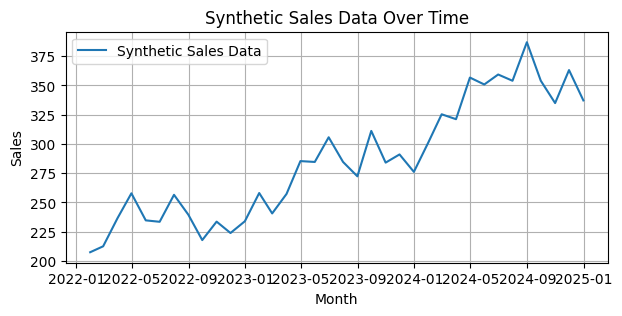

In [ ]:
# -----------------------------------------------------------
# Plot synthetic sales data
# -----------------------------------------------------------
plt.figure(figsize=(7, 3))
plt.plot(data.index, data["Sales"], label="Synthetic Sales Data")
plt.title("Synthetic Sales Data Over Time")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# -----------------------------------------------------------
# 2. Naïve Forecast (last known value)
# -----------------------------------------------------------
naive_forecast = data["Sales"].shift(1)



In [ ]:
# -----------------------------------------------------------
# Cumulative Mean Forecast
# -----------------------------------------------------------
data["Cumulative_Mean"] = data["Sales"].expanding().mean()

In [ ]:
# -----------------------------------------------------------
# 3. Moving Average Forecast (window = 3)
# -----------------------------------------------------------
data["MA_3"] = data["Sales"].rolling(window=3).mean()





In [ ]:
# -----------------------------------------------------------
# 4. Exponential Smoothing
# -----------------------------------------------------------
exp_model = SimpleExpSmoothing(data["Sales"], initialization_method="heuristic").fit(smoothing_level=0.3)
data["Exp_Smooth"] = exp_model.fittedvalues

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


In [ ]:
# -----------------------------------------------------------
# 5. Polynomial Trend (degree = 2)
# -----------------------------------------------------------
X = np.arange(len(data)).reshape(-1, 1)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
model_poly = LinearRegression().fit(X_poly, data["Sales"])
data["Poly_Trend"] = model_poly.predict(X_poly)



In [ ]:
# -----------------------------------------------------------
# 6. Autoregressive Model (AR(1))
# -----------------------------------------------------------
ar_model = AutoReg(data["Sales"], lags=1).fit()
data["AR(1)"] = ar_model.fittedvalues



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


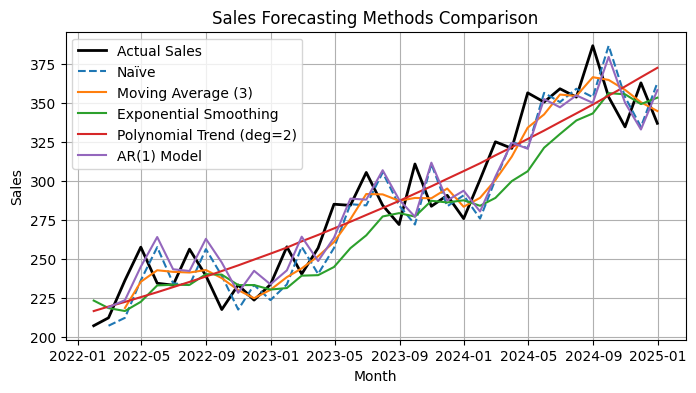

In [ ]:
# -----------------------------------------------------------
# 7. Plot all results
# -----------------------------------------------------------
plt.figure(figsize=(8,4))
plt.plot(data.index, data["Sales"], label="Actual Sales", color="black", linewidth=2)
plt.plot(data.index, naive_forecast, "--", label="Naïve")
plt.plot(data.index, data["MA_3"], label="Moving Average (3)")
plt.plot(data.index, data["Exp_Smooth"], label="Exponential Smoothing")
plt.plot(data.index, data["Poly_Trend"], label="Polynomial Trend (deg=2)")
plt.plot(data.index, data["AR(1)"], label="AR(1) Model")
plt.title("Sales Forecasting Methods Comparison")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()



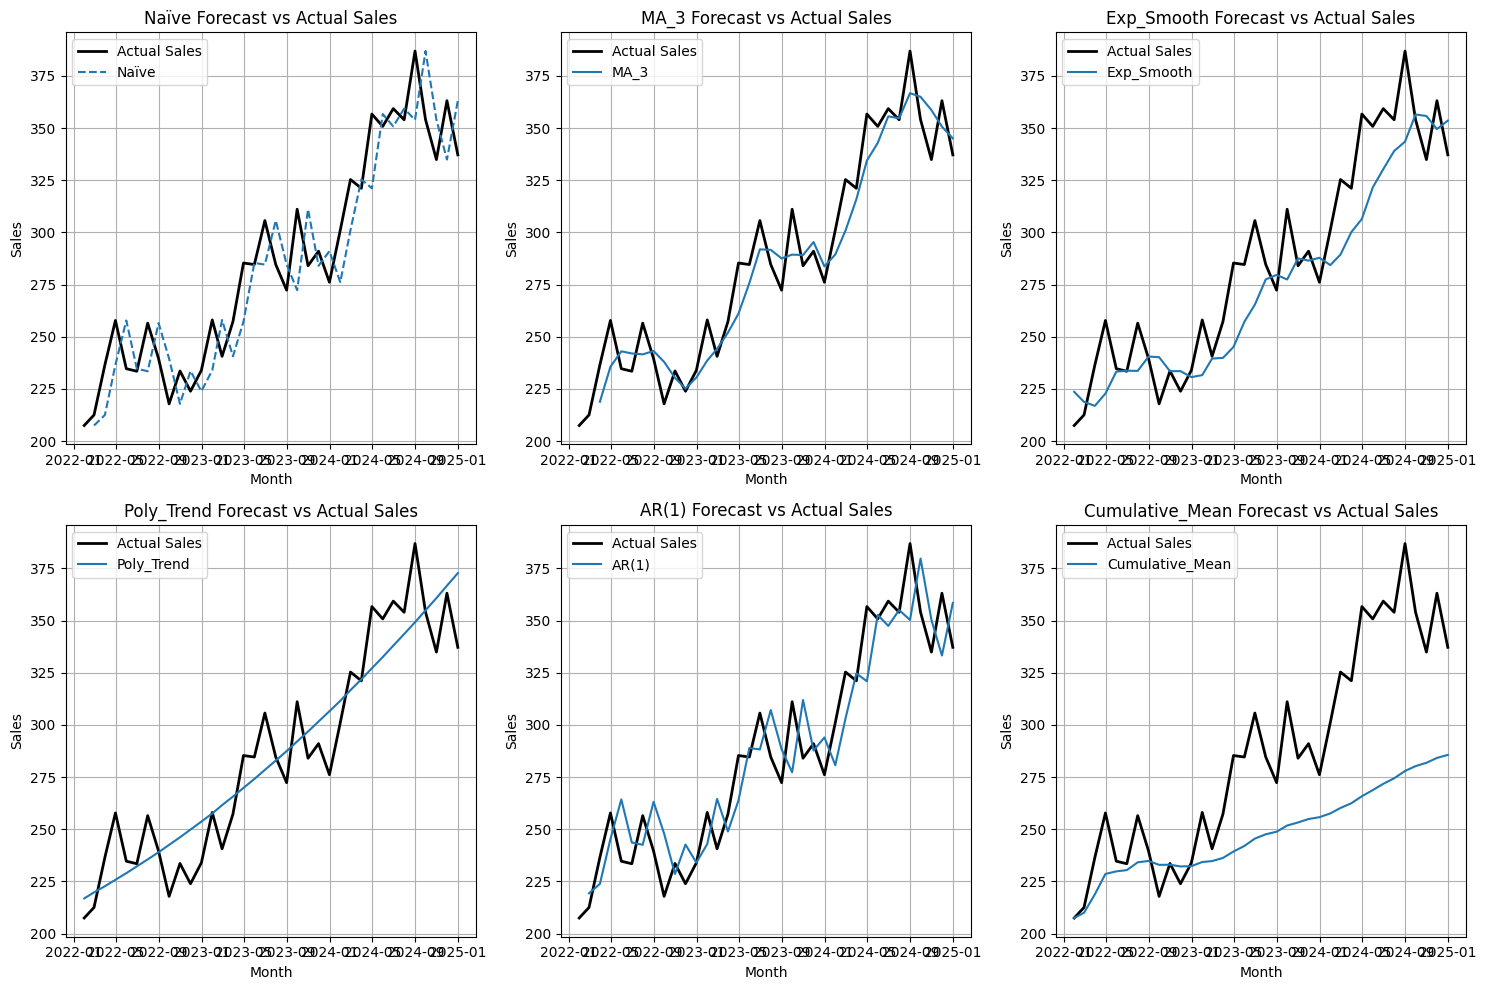

In [ ]:
# -----------------------------------------------------------
# Plot each forecast against actual sales
# -----------------------------------------------------------
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

forecast_cols = ["Naïve", "MA_3", "Exp_Smooth", "Poly_Trend", "AR(1)", "Cumulative_Mean"]

for i, col in enumerate(forecast_cols):
    axes[i].plot(data.index, data["Sales"], label="Actual Sales", color="black", linewidth=2)
    if col == "Naïve":
        axes[i].plot(data.index, naive_forecast, "--", label=col)
    else:
        axes[i].plot(data.index, data[col], label=col)
    axes[i].set_title(f"{col} Forecast vs Actual Sales")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Sales")
    axes[i].legend()
    axes[i].grid(True)

# Hide the last unused subplot
if len(forecast_cols) < len(axes):
    for j in range(len(forecast_cols), len(axes)):
        axes[j].axis('off')


plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------------------
# 8. Show comparison table (last few values)
# -----------------------------------------------------------
display_cols = ["Sales", "Naïve", "MA_3", "Exp_Smooth", "Poly_Trend", "AR(1)", "Cumulative_Mean"]
print(data[display_cols].tail(10).round(2))

             Sales   Naïve    MA_3  Exp_Smooth  Poly_Trend   AR(1)  \
Month                                                                
2024-03-31  321.14  325.34  315.86      300.15      321.85  324.68   
2024-04-30  356.71  321.14  334.40      306.45      327.13  320.93   
2024-05-31  350.80  356.71  342.88      321.53      332.51  352.73   
2024-06-30  359.32  350.80  355.61      330.31      337.98  347.45   
2024-07-31  353.98  359.32  354.70      339.01      343.54  355.07   
2024-08-31  386.91  353.98  366.74      343.50      349.20  350.29   
2024-09-30  354.04  386.91  364.98      356.53      354.95  379.73   
2024-10-31  334.90  354.04  358.62      355.78      360.78  350.34   
2024-11-30  363.11  334.90  350.68      349.52      366.72  333.23   
2024-12-31  337.17  363.11  345.06      353.59      372.74  358.45   

            Cumulative_Mean  
Month                        
2024-03-31           262.44  
2024-04-30           265.81  
2024-05-31           268.74  
2024-06-3

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# -----------------------------------------------------------
# 9. Calculate and display performance metrics (MSE and RMSE)
# -----------------------------------------------------------
forecast_cols = ["Naïve", "MA_3", "Exp_Smooth", "Poly_Trend", "AR(1)", "Cumulative_Mean"]
metrics = {}

# Create a temporary DataFrame with actual sales and all forecasts
temp_df = data[["Sales"]].copy()
temp_df["Naïve"] = naive_forecast
for col in ["MA_3", "Exp_Smooth", "Poly_Trend", "AR(1)", "Cumulative_Mean"]:
    temp_df[col] = data[col]

# Drop rows with any NaN values from the temporary DataFrame
temp_df.dropna(inplace=True)

actual_sales_aligned = temp_df["Sales"]

for col in forecast_cols:
    predicted_sales_aligned = temp_df[col]

    mse = mean_squared_error(actual_sales_aligned, predicted_sales_aligned)
    rmse = np.sqrt(mse)
    metrics[col] = {"MSE": mse, "RMSE": rmse}

metrics_df = pd.DataFrame(metrics).T
print("\nPerformance Metrics:")
display(metrics_df.round(2))


Performance Metrics:


,MSE,RMSE
Naïve,453.87,21.30
MA_3,188.02,13.71
Exp_Smooth,541.18,23.26
Poly_Trend,360.34,18.98
AR(1),410.26,20.25
Cumulative_Mean,2539.57,50.39


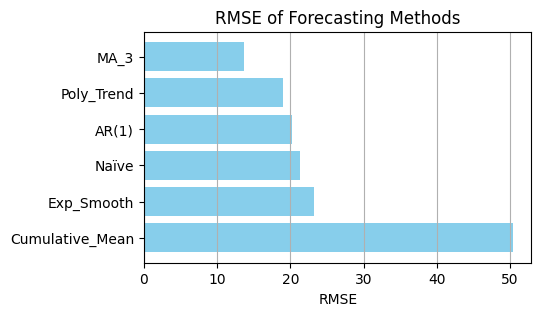

In [ ]:
# -----------------------------------------------------------
# 10. Visualize performance metrics (RMSE)
# -----------------------------------------------------------
metrics_df_sorted = metrics_df.sort_values("RMSE", ascending=False)

plt.figure(figsize=(5, 3))
plt.barh(metrics_df_sorted.index, metrics_df_sorted["RMSE"], color='skyblue')
plt.xlabel("RMSE")
plt.title("RMSE of Forecasting Methods")
plt.grid(axis='x')
plt.show()